# Clustering

Clustering finds groups in data without labels. This notebook segments wholesale customers by their
spending across product categories — a real use of unsupervised learning — comparing K-means and
DBSCAN, and showing why feature scaling is essential for distance-based methods.

## Learning objectives

By the end of this notebook you will be able to:

- standardise features before distance-based clustering and explain why;
- choose `k` with the elbow method and the silhouette score;
- fit K-means and DBSCAN and contrast their assumptions;
- identify noise points and explain what DBSCAN's `eps` controls;
- visualise clusters in two dimensions with PCA.

## Concept

**K-means** partitions points into `k` clusters by minimising the within-cluster sum of squared
distances. It is fast and simple but assumes roughly spherical, equally sized clusters and forces
every point into a cluster. The number of clusters `k` must be chosen; the **elbow** method looks
for where adding clusters stops reducing inertia much, and the **silhouette score** measures how
well each point fits its own cluster versus the next nearest.

**DBSCAN** groups points that are densely packed, marking points in sparse regions as noise. It
needs no `k`, can find irregular shapes, and identifies outliers — but `eps` (the neighbourhood
radius) and `min_samples` are sensitive, and clusters can vary in density. **HDBSCAN** extends
DBSCAN by varying the density threshold automatically, but it is an optional dependency here.

Both methods rely on distance, so a variable measured in large numbers (annual spend in monetary
units) would dominate unless every feature is **standardised** to zero mean and unit variance.

## Worked example

### Load and scale

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import ml
from ds_practice import load_wholesale, set_seed, scatterplot

set_seed(42)
wholesale = load_wholesale()
print("shape:", wholesale.shape)
display(wholesale.head())
print("\nspend ranges:")
display(wholesale.describe().loc[["min", "max", "mean"]].round(0))

shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



spend ranges:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
min,1.0,1.0,3.0,55.0,3.0,25.0,3.0,3.0
max,2.0,3.0,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
mean,1.0,3.0,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0


### K-means: choosing k

Inertia always falls as `k` grows, so the elbow is where the fall flattens. The silhouette peaks
at the most separated solution.

In [2]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

features = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X = StandardScaler().fit_transform(wholesale[features])

rows = []
for k in range(2, 9):
    labels = ml.make_cluster("kmeans", n_clusters=k).fit_predict(X)
    rows.append({
        "k": k,
        "inertia": round(ml.make_cluster("kmeans", n_clusters=k).fit(X).inertia_, 1),
        "silhouette": round(silhouette_score(X, labels), 3),
    })
display(pd.DataFrame(rows))

,k,inertia,silhouette
0,2,1956.1,0.547
1,3,1608.4,0.548
2,4,1317.8,0.348
3,5,1058.8,0.369
4,6,915.7,0.378
5,7,825.4,0.334
6,8,737.4,0.320


### Fit the chosen K-means

Silhouette often favours two clusters on this data, separating retail from hospitality customers.

In [3]:
kmeans = ml.make_cluster("kmeans", n_clusters=2).fit(X)
wholesale = wholesale.assign(cluster=kmeans.labels_)
print(wholesale.groupby("cluster")[features].mean().round(0))

           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                 
0        12157.0   4028.0   5403.0  3066.0            1668.0      1257.0
1        10803.0  19282.0  27390.0  3117.0           12140.0      3569.0


### DBSCAN and noise

DBSCAN marks sparse customers as noise. The count of noise points and clusters depends strongly on
`eps`.

In [4]:
dbscan = ml.make_cluster("dbscan", eps=1.5, min_samples=10).fit(X)
labels = dbscan.labels_
print("clusters:", sorted(set(labels) - {-1}))
print("noise points:", int((labels == -1).sum()), "of", len(labels))

rows = []
for eps in (1.0, 1.5, 2.0, 2.5):
    found = ml.make_cluster("dbscan", eps=eps, min_samples=10).fit_predict(X)
    rows.append({
        "eps": eps,
        "clusters": len(set(found) - {-1}),
        "noise": int((found == -1).sum()),
    })
display(pd.DataFrame(rows))

clusters: [np.int64(0)]
noise points: 29 of 440


,eps,clusters,noise
0,1.0,1,54
1,1.5,1,29
2,2.0,1,17
3,2.5,1,13


### Visualise with PCA

PCA projects the six standardised features onto two axes so the clusters can be seen. The projection
loses information, so use it for display, not for clustering.

explained variance ratio: [0.441 0.284]


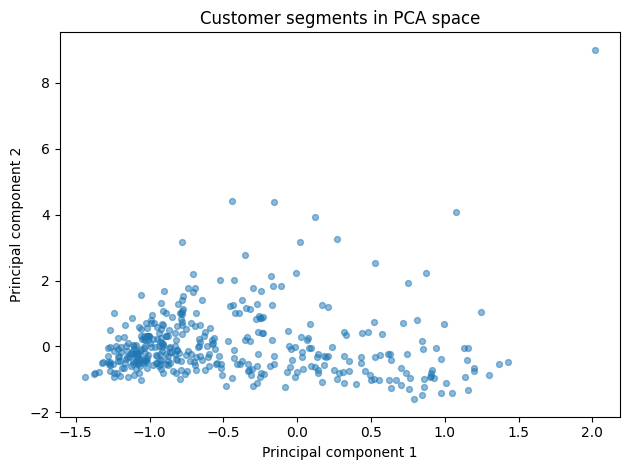

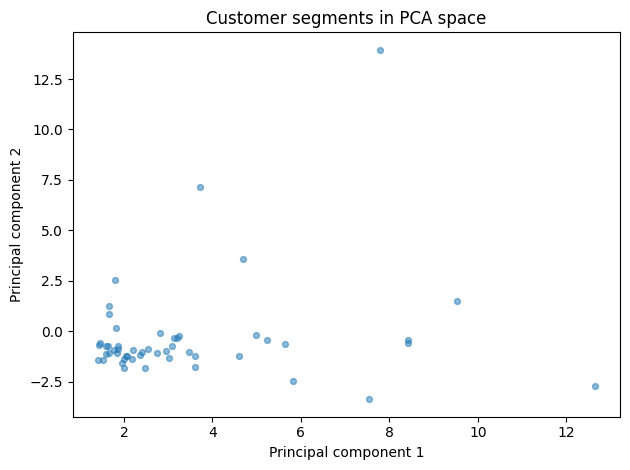

In [5]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(X)
plot_frame = pd.DataFrame({"pc1": coords[:, 0], "pc2": coords[:, 1], "cluster": kmeans.labels_.astype(str)})
for cluster, group in plot_frame.groupby("cluster"):
    scatterplot(group["pc1"], group["pc2"], title="Customer segments in PCA space",
                xlabel="Principal component 1", ylabel="Principal component 2")
print("explained variance ratio:", PCA(n_components=2, random_state=42).fit(X).explained_variance_ratio_.round(3))

## Exercises

1. **Scaling matters.** Cluster the raw (unscaled) data with K-means and compare the cluster
   assignment with the scaled version. Which feature dominates the unscaled result?
2. **Silhouette by k.** Plot the silhouette score against `k` and state the best `k`. Does it agree
   with the elbow?
3. **Optional HDBSCAN.** Try to import `hdbscan`, fit it with `min_cluster_size=15`, and fall back
   to DBSCAN with a printed message if it is not installed. Compare the number of noise points.

## Limitations

Cluster labels have no ground truth here, so "correct" is a judgement about usefulness, not
accuracy. K-means imposes spherical clusters and assigns outliers to the nearest one; DBSCAN's
result swings with `eps`. Standardising gives every product category equal influence regardless of
business importance. The dataset is small and from one region, so segments may not transfer. PCA
coordinates are a lossy summary and should never replace the original features when interpreting
clusters.